# Loan Approval Prediction — Exploratory Data Analysis

We explore the **Analytics Vidhya / Dream Housing Finance** loan dataset to understand which applicant attributes drive loan approvals.

**Dataset**: 614 loan applications with 12 input features (demographic + financial) and a binary `Loan_Status` target (Y = approved, N = denied).

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

%matplotlib inline

## 2. Load Data

In [2]:
df = pd.read_csv("data/loan.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## 3. Dataset Overview

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [4]:
df.describe(include='all').round(2)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
count,614,601,611,599,614,582,614.00,614.00,592.00,600.00,564.00,614,614
unique,614,2,2,4,2,2,NaN,NaN,NaN,NaN,NaN,3,2
top,LP001002,Male,Yes,0,Graduate,No,NaN,NaN,NaN,NaN,NaN,Semiurban,Y
freq,1,489,398,345,480,500,NaN,NaN,NaN,NaN,NaN,233,422
mean,NaN,NaN,NaN,NaN,NaN,NaN,5403.46,1621.25,146.41,342.00,0.84,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,6109.04,2926.25,85.59,65.12,0.36,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,150.00,0.00,9.00,12.00,0.00,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,2877.50,0.00,100.00,360.00,1.00,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,3812.50,1188.50,128.00,360.00,1.00,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,5795.00,2297.25,168.00,360.00,1.00,NaN,NaN


In [5]:
print(f"Duplicate rows : {df.duplicated().sum()}")
print(f"Unique Loan_IDs: {df['Loan_ID'].nunique()}")

Duplicate rows : 0
Unique Loan_IDs: 614


## 4. Missing / Invalid Values

Gender              13
Married              3
Dependents          15
Self_Employed       32
LoanAmount          22
Loan_Amount_Term    14
Credit_History      50
dtype: int64


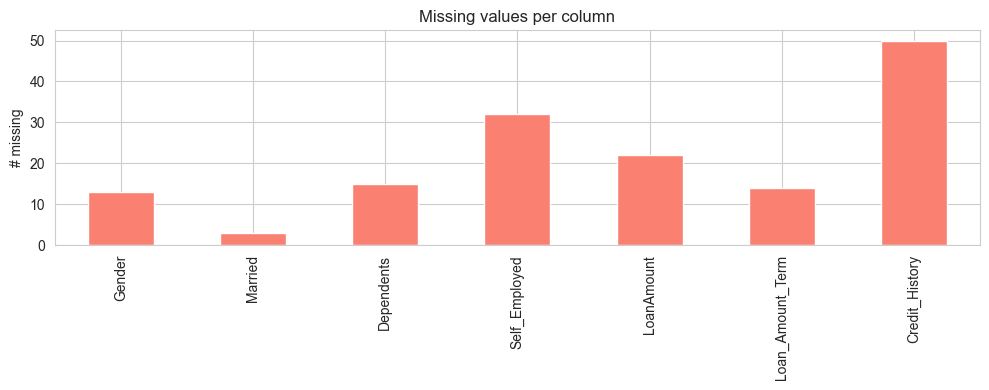

In [6]:
missing = df.isnull().sum()
print(missing[missing>0])

plt.figure(figsize=(10, 4))
missing[missing>0].plot(kind="bar", color="salmon")
plt.title("Missing values per column")
plt.ylabel("# missing"); plt.tight_layout(); plt.show()

## 5. Target Variable Distribution

/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_74907/1119299771.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Loan_Status", data=df, palette="Set2", ax=axes[0], order=["Y","N"])
/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_74907/1119299771.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Approved (Y)", "Denied (N)"])


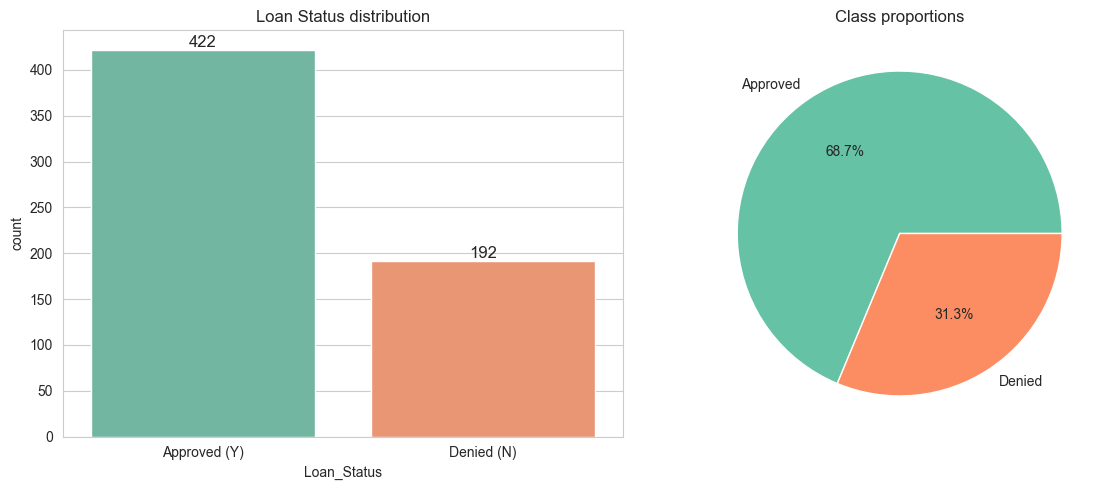

Approval rate: 68.7%


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x="Loan_Status", data=df, palette="Set2", ax=axes[0], order=["Y","N"])
axes[0].set_xticklabels(["Approved (Y)", "Denied (N)"])
axes[0].set_title("Loan Status distribution")
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height())}",
                     (p.get_x()+p.get_width()/2., p.get_height()),
                     ha="center", va="bottom", fontsize=12)

df["Loan_Status"].value_counts().plot.pie(
    labels=["Approved","Denied"], autopct="%1.1f%%",
    colors=["#66c2a5","#fc8d62"], ax=axes[1])
axes[1].set_ylabel(""); axes[1].set_title("Class proportions")
plt.tight_layout(); plt.show()
print(f"Approval rate: {(df['Loan_Status']=='Y').mean()*100:.1f}%")

## 6. Univariate — Numeric Features

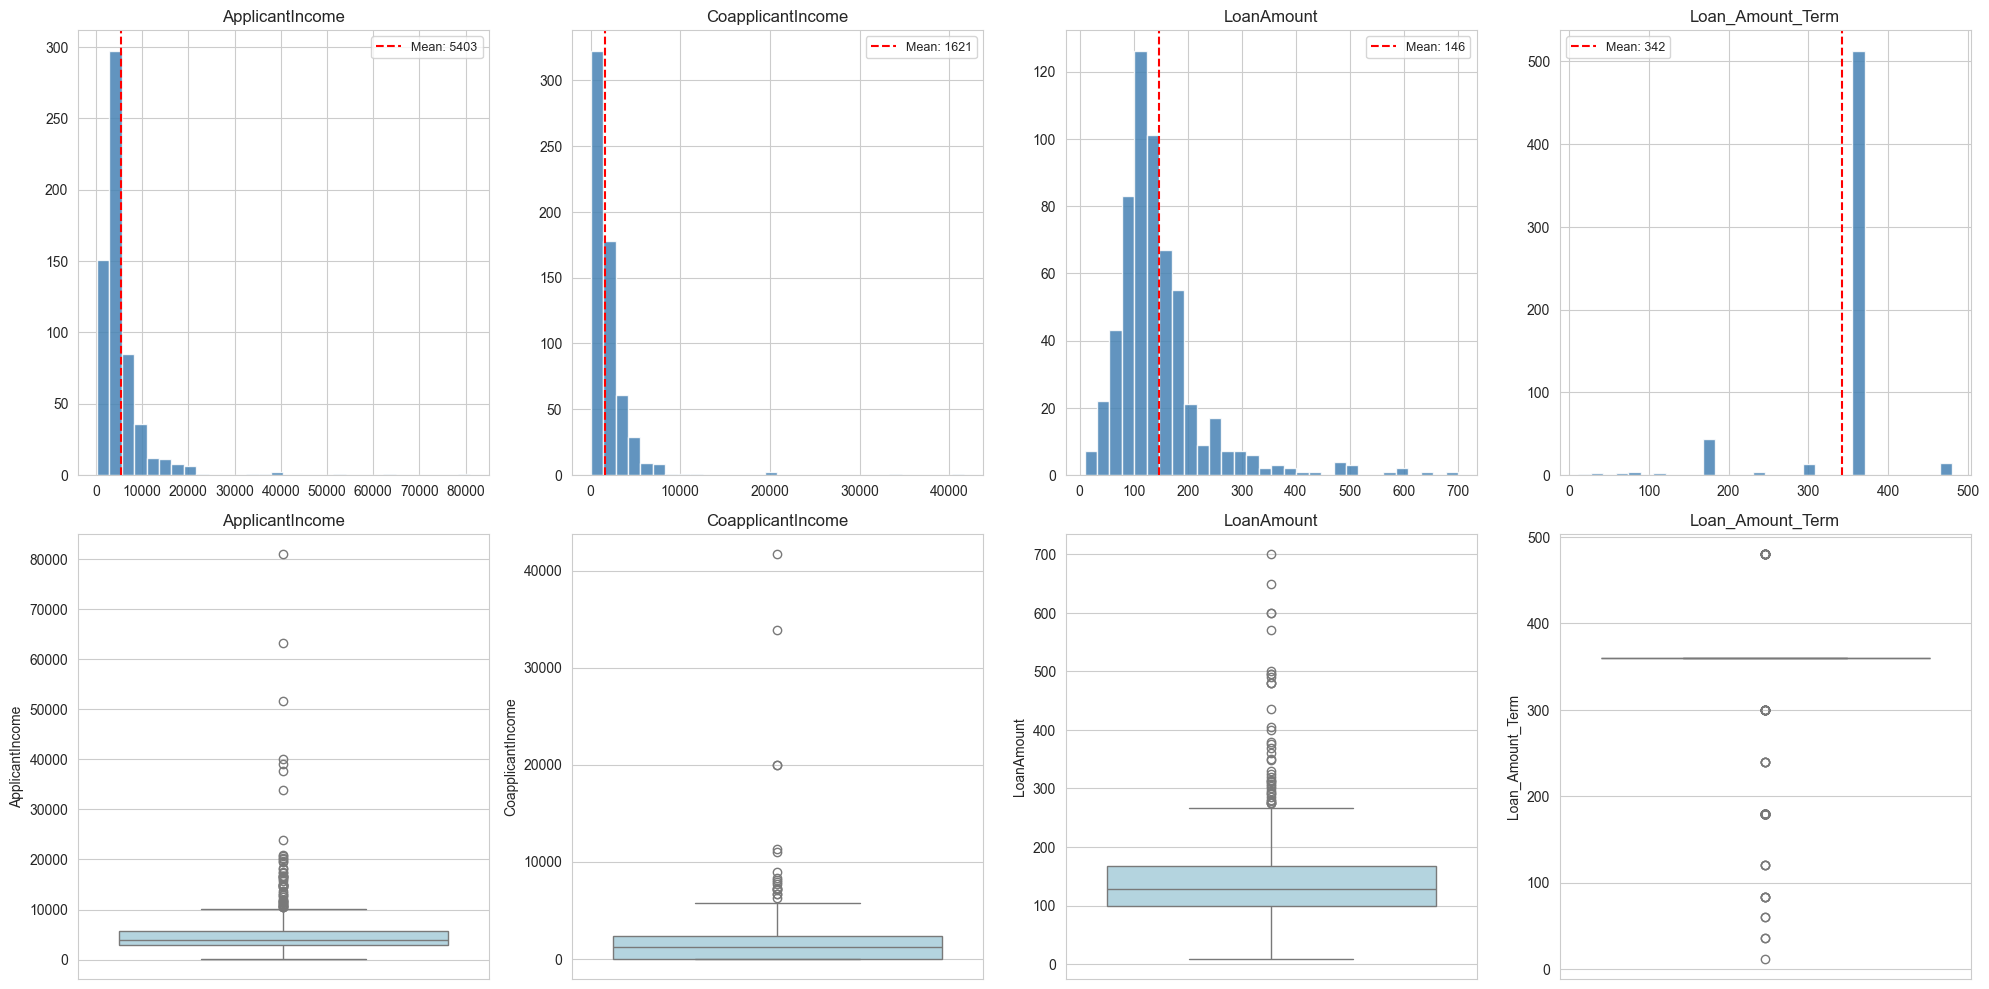

In [8]:
num_features = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount", "Loan_Amount_Term"]
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# Histograms (top row)
for i, col in enumerate(num_features):
    df[col].dropna().hist(bins=30, color="steelblue", edgecolor="white", alpha=0.85, ax=axes[0,i])
    axes[0,i].axvline(df[col].mean(), color="red", linestyle="--",
                      label=f"Mean: {df[col].mean():.0f}")
    axes[0,i].set_title(col); axes[0,i].legend(fontsize=9)

# Box plots (bottom row)
for i, col in enumerate(num_features):
    sns.boxplot(y=df[col], ax=axes[1,i], color="lightblue")
    axes[1,i].set_title(col)

plt.tight_layout(); plt.show()

## 7. Univariate — Categorical Features

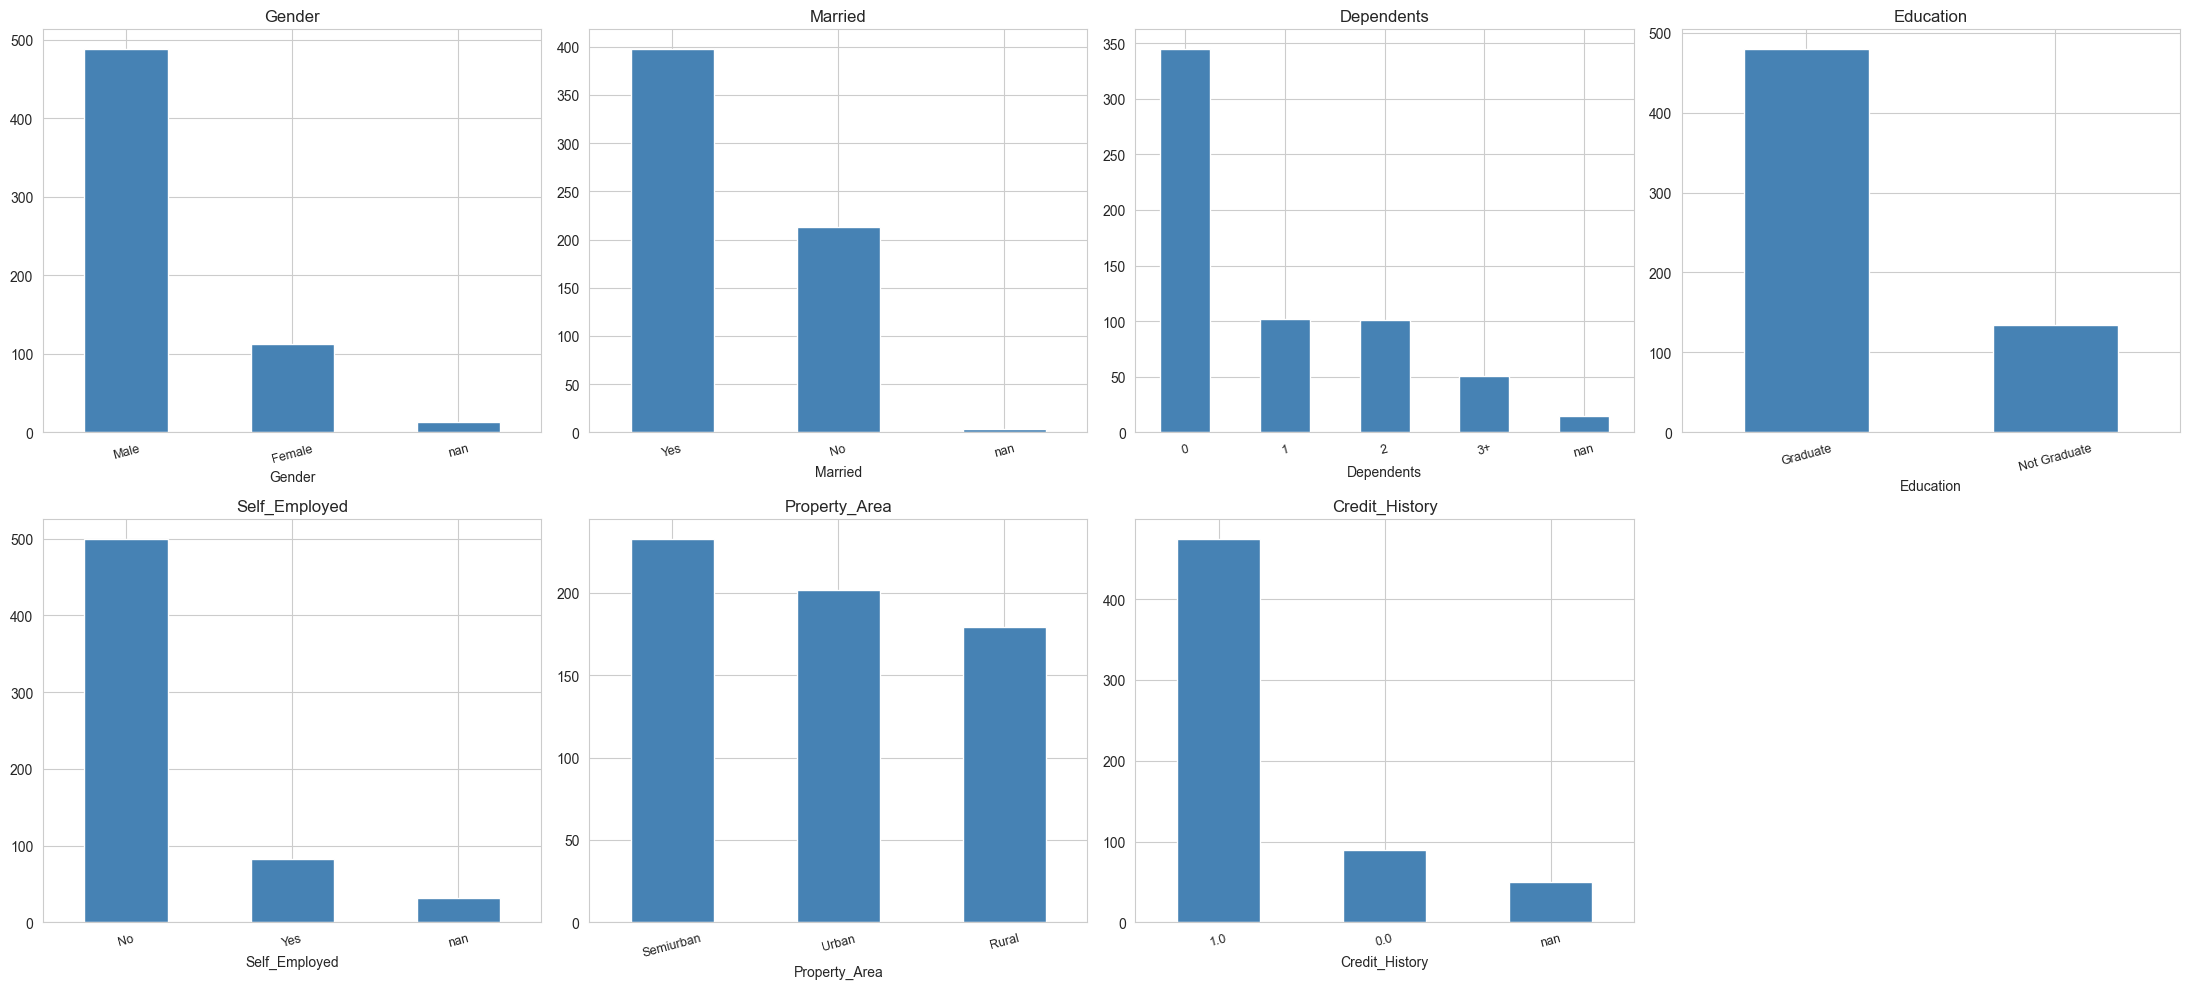

In [9]:
cat_features = ["Gender","Married","Dependents","Education","Self_Employed","Property_Area","Credit_History"]
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()
for i, col in enumerate(cat_features):
    df[col].value_counts(dropna=False).plot(kind="bar", color="steelblue", ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis="x", labelsize=9, rotation=15)
for j in range(len(cat_features), len(axes)):
    axes[j].axis("off")
plt.tight_layout(); plt.show()

## 8. Bivariate — Numeric Features vs Loan_Status

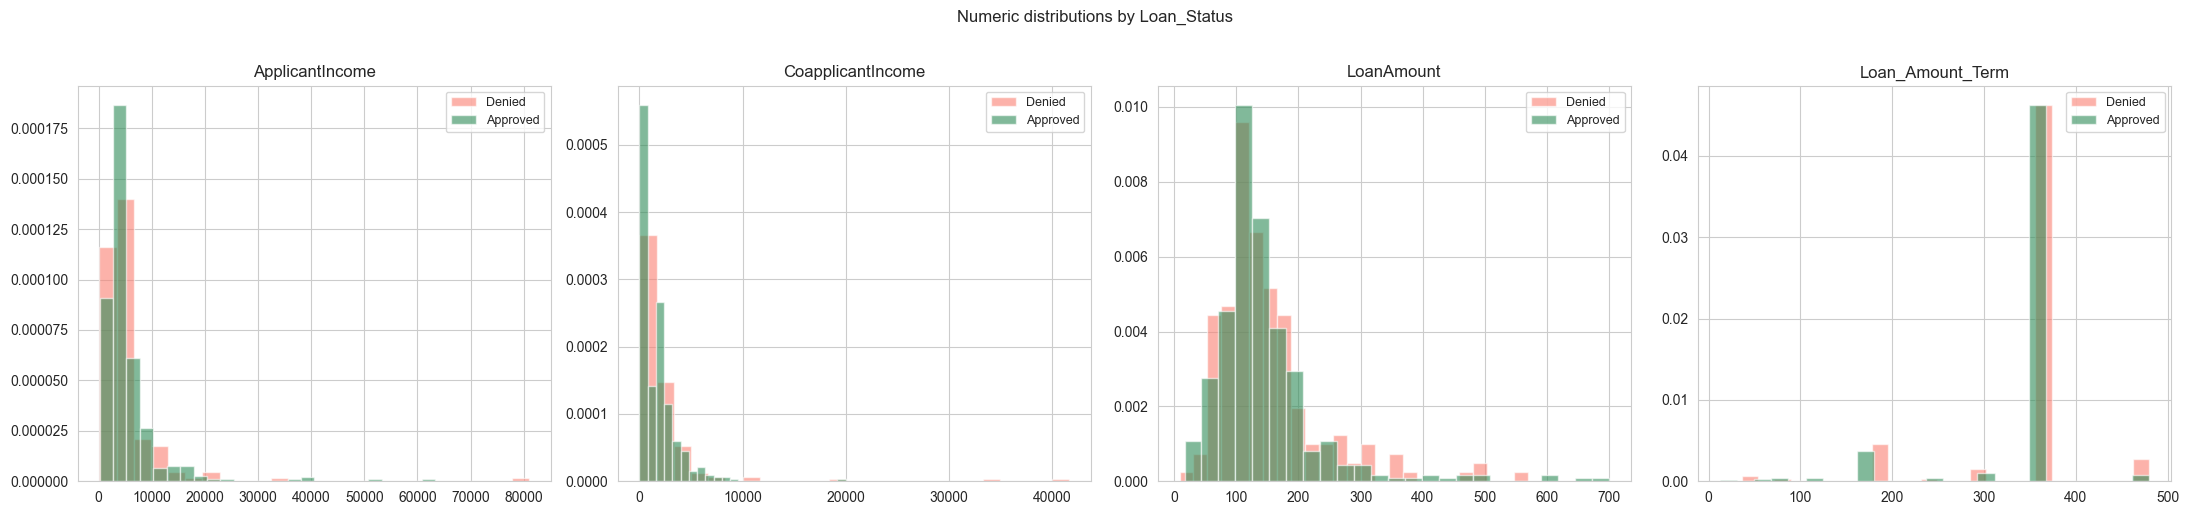

In [10]:
df_bin = df.copy()
df_bin["target"] = (df_bin["Loan_Status"] == "Y").astype(int)

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for i, col in enumerate(num_features):
    for s, color, label in [(0, "salmon", "Denied"), (1, "seagreen", "Approved")]:
        sub = df_bin[df_bin["target"] == s][col].dropna()
        axes[i].hist(sub, bins=25, alpha=0.6, color=color, label=label, density=True)
    axes[i].set_title(col); axes[i].legend(fontsize=9)
plt.suptitle("Numeric distributions by Loan_Status", y=1.02)
plt.tight_layout(); plt.show()

/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_74907/2394424481.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Loan_Status", y=col, data=df, palette="Set2", order=["N","Y"], ax=axes[i])
/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_74907/2394424481.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["Denied","Approved"])


/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_74907/2394424481.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Loan_Status", y=col, data=df, palette="Set2", order=["N","Y"], ax=axes[i])


/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_74907/2394424481.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["Denied","Approved"])
/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_74907/2394424481.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Loan_Status", y=col, data=df, palette="Set2", order=["N","Y"], ax=axes[i])
/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_74907/2394424481.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["Denied","Approved"])
/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_74907/2394424481.py:3: FutureWarning: 

Passing `palette` witho

/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_74907/2394424481.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["Denied","Approved"])


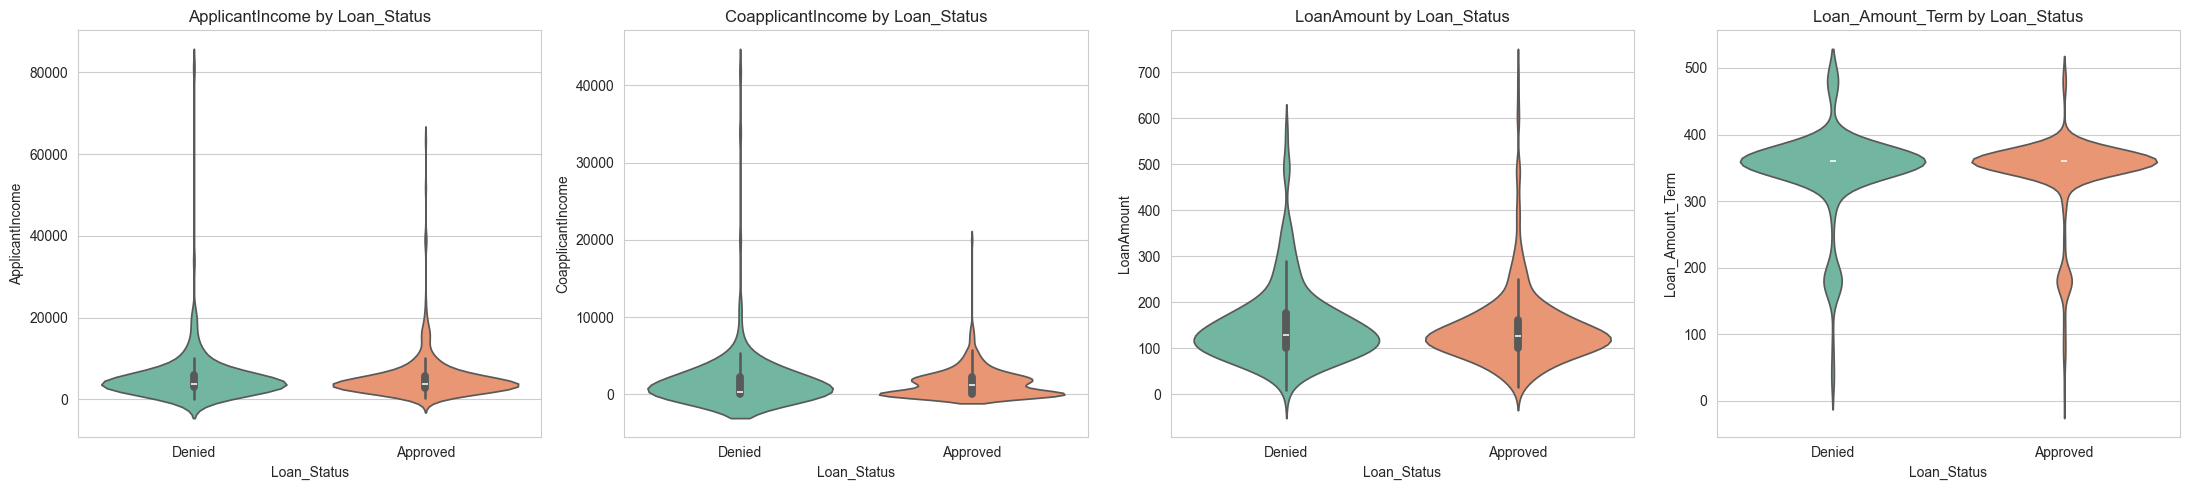

             ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term
Loan_Status                                                                  
N                     5446.1             1877.8       151.2             344.1
Y                     5384.1             1504.5       144.3             341.1


In [11]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for i, col in enumerate(num_features):
    sns.violinplot(x="Loan_Status", y=col, data=df, palette="Set2", order=["N","Y"], ax=axes[i])
    axes[i].set_xticklabels(["Denied","Approved"])
    axes[i].set_title(f"{col} by Loan_Status")
plt.tight_layout(); plt.show()

print(df.groupby("Loan_Status")[num_features].mean().round(1))

## 9. Bivariate — Categorical Features vs Loan_Status

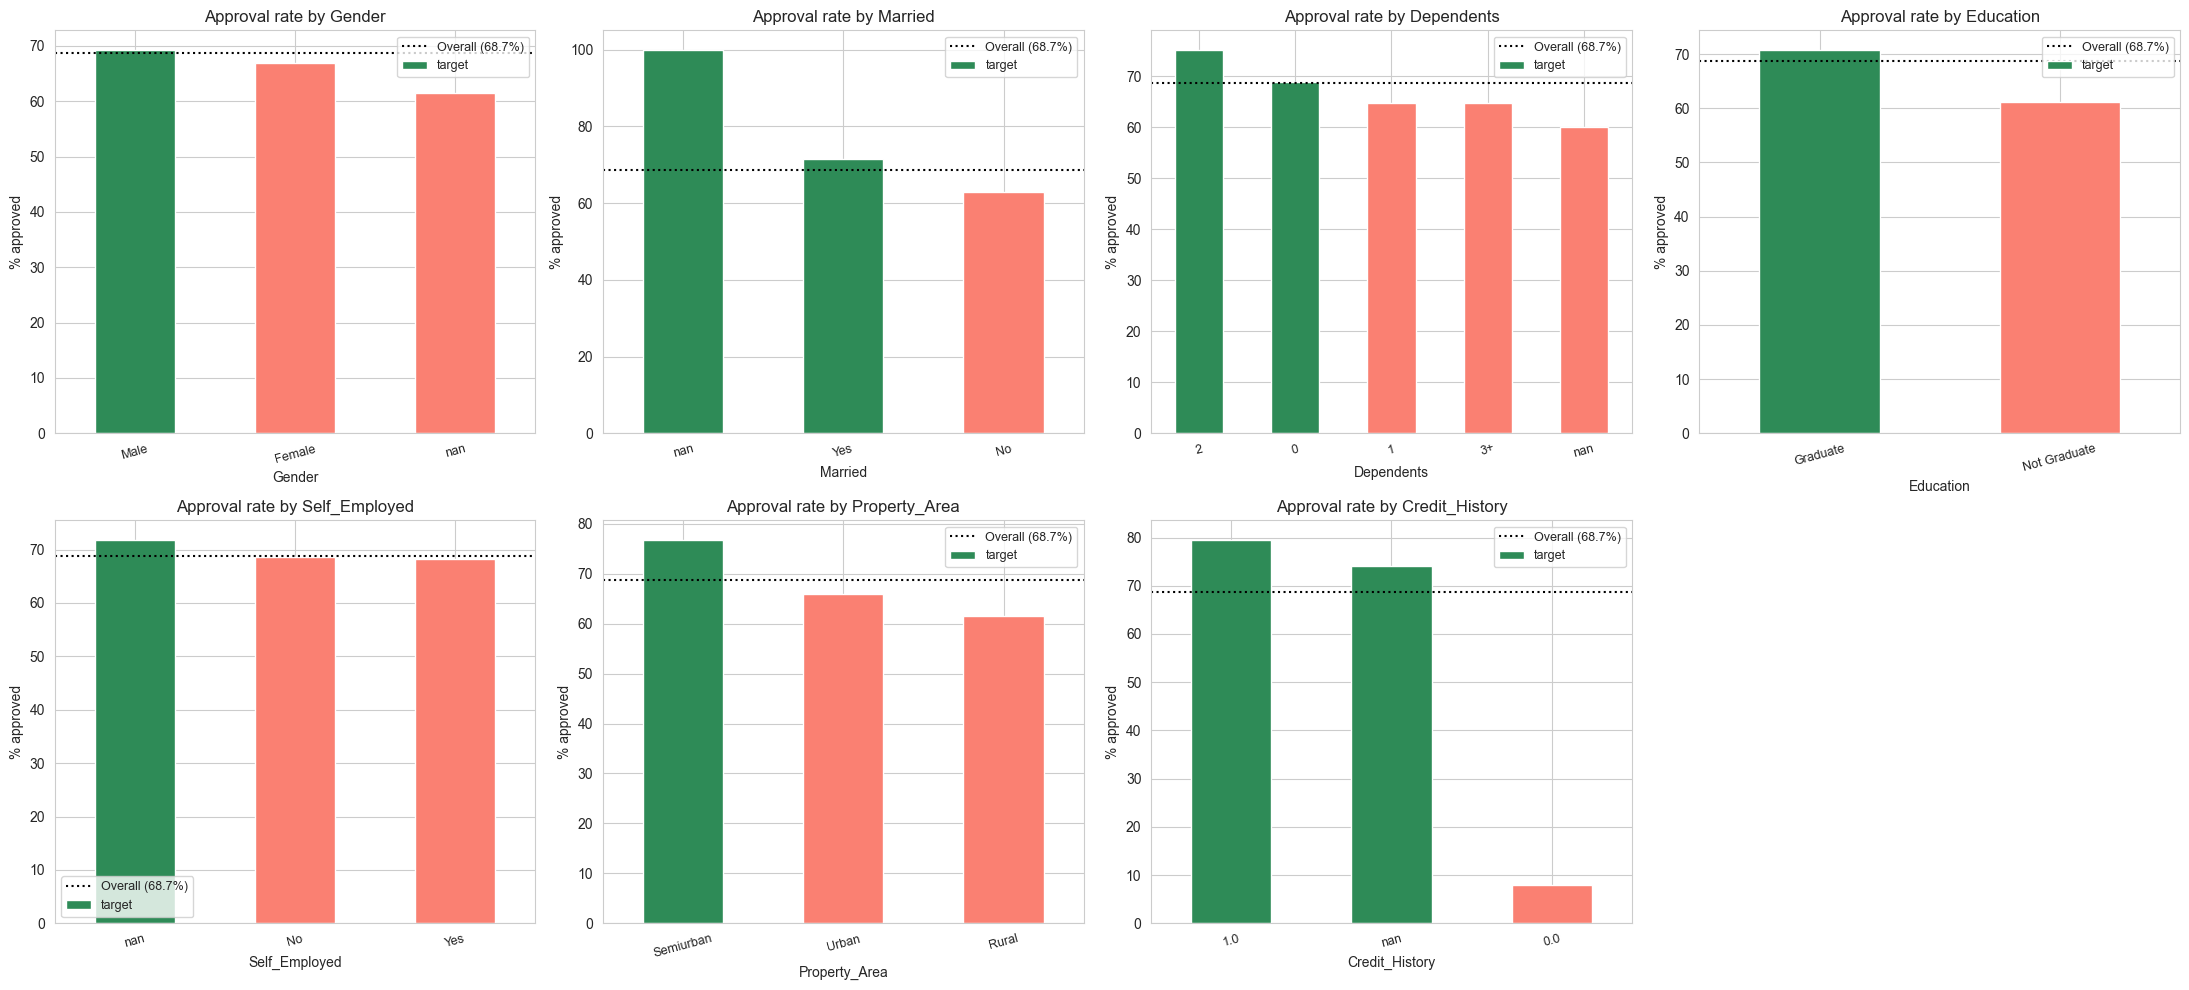

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()
for i, col in enumerate(cat_features):
    rate = df_bin.groupby(col, dropna=False)["target"].mean() * 100
    rate.sort_values(ascending=False).plot(
        kind="bar",
        color=["seagreen" if r > df_bin["target"].mean()*100 else "salmon" for r in rate.sort_values(ascending=False)],
        ax=axes[i])
    axes[i].axhline(df_bin["target"].mean()*100, color="black", linestyle=":",
                    label=f"Overall ({df_bin['target'].mean()*100:.1f}%)")
    axes[i].set_title(f"Approval rate by {col}")
    axes[i].set_ylabel("% approved")
    axes[i].tick_params(axis="x", labelsize=9, rotation=15)
    axes[i].legend(fontsize=9)
for j in range(len(cat_features), len(axes)):
    axes[j].axis("off")
plt.tight_layout(); plt.show()

## 10. Credit_History Deep-Dive

Credit history is famously the dominant signal in this dataset.

In [13]:
ct = pd.crosstab(df["Credit_History"], df["Loan_Status"], dropna=False)
ct["% approved"] = (ct["Y"] / (ct["Y"] + ct["N"]) * 100).round(1)
ct

Loan_Status,N,Y,% approved
Credit_History,,,
0.0,82,7,7.9
1.0,97,378,79.6
NaN,13,37,74.0


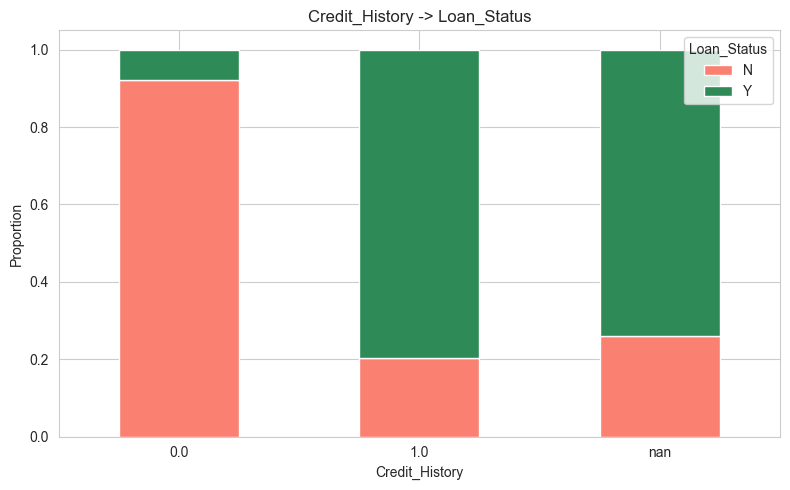

In [14]:
pd.crosstab(df["Credit_History"], df["Loan_Status"], normalize="index", dropna=False).plot(
    kind="bar", stacked=True, color=["salmon","seagreen"], figsize=(8, 5))
plt.title("Credit_History -> Loan_Status")
plt.ylabel("Proportion"); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

## 11. Income & Loan Amount Joint View

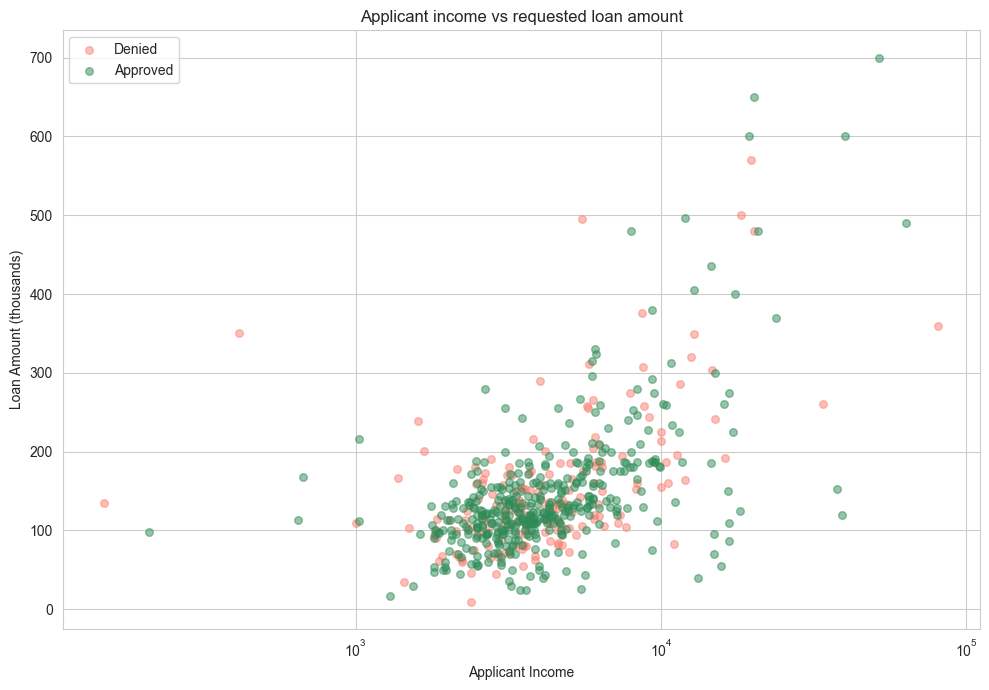

In [15]:
plt.figure(figsize=(10, 7))
for s, color, label in [("N", "salmon", "Denied"), ("Y", "seagreen", "Approved")]:
    sub = df[df["Loan_Status"] == s]
    plt.scatter(sub["ApplicantIncome"], sub["LoanAmount"],
                c=color, alpha=0.5, label=label, s=30)
plt.xlabel("Applicant Income"); plt.ylabel("Loan Amount (thousands)")
plt.title("Applicant income vs requested loan amount")
plt.xscale("log")
plt.legend(); plt.tight_layout(); plt.show()

## 12. Pair Plot — Top Numeric Features

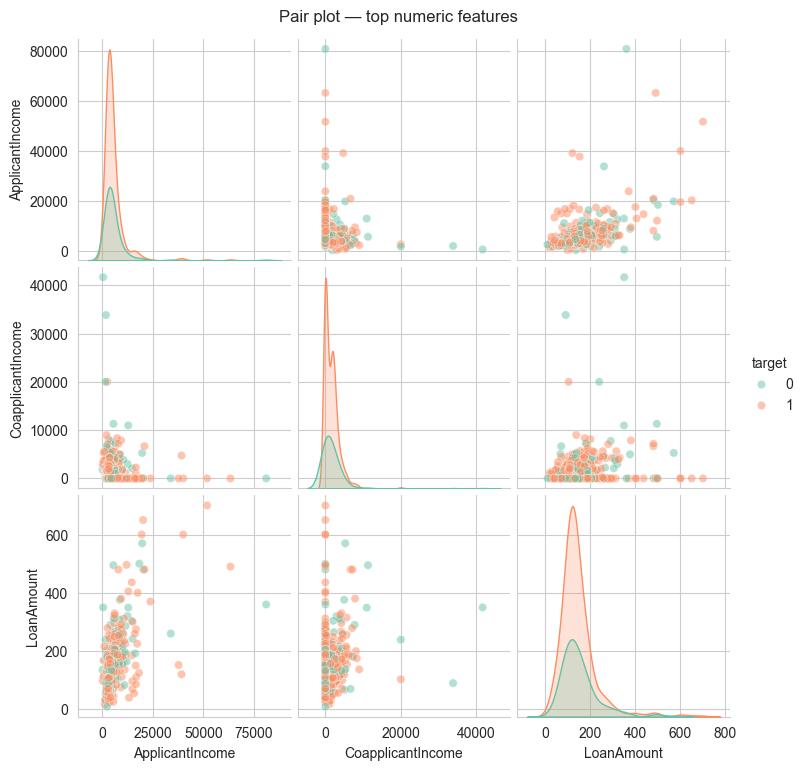

In [16]:
plot_df = df_bin[["ApplicantIncome","CoapplicantIncome","LoanAmount","target"]].dropna()
sns.pairplot(plot_df, hue="target", palette="Set2", diag_kind="kde",
             plot_kws={"alpha": 0.5})
plt.suptitle("Pair plot — top numeric features", y=1.02)
plt.show()

## 13. Key EDA Findings

| # | Finding |
|---|--------|
| 1 | **Class balance**: ~68.7% approved vs ~31.3% denied — moderately imbalanced |
| 2 | **Credit_History is the dominant predictor**: ~79% approval when `Credit_History == 1`, ~8% when `Credit_History == 0` |
| 3 | **Married applicants are approved more often** (~71%) than singles (~63%) |
| 4 | **Education matters**: graduates get approved more (~71%) than non-graduates (~61%) |
| 5 | **Property_Area = Semiurban** has the highest approval rate (~77%) — even higher than Urban |
| 6 | **Income is mildly informative**: approved applicants have slightly lower mean income (5384) than denied (5446) — counterintuitive at first glance, explained by Credit_History being more important |
| 7 | **6 of 12 columns have missing values** (`Gender`, `Married`, `Dependents`, `Self_Employed`, `LoanAmount`, `Loan_Amount_Term`, `Credit_History`) — need careful imputation |
| 8 | **`Dependents = "3+"` is a string token** that needs to become `3` for numeric handling |